# return_distribution_analysis.ipynb
###  Statistical Analysis: Return Distributions, Q-Q Plots, and Significance Testing

**Scope of this notebook**

This notebook documents the distributional analysis of the return series: descriptive
statistics, histogram shape, a Q-Q plot against the normal distribution, and formal
significance testing (Jarque–Bera) for normality. It is written to stand alone as a
reference for later weeks of the project (frequency analysis, feature engineering,
GARCH modeling, and the final write-up), so each result includes both the number and
what it implies for later modeling choices.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


## 2. Load data

In [2]:
df = pd.read_csv('cleaned_data_with_returns__1_.csv')
df['Date'] = pd.to_datetime(df['Date'])  # ISO format (YYYY-MM-DD) in this file
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Rows: 2670
Date range: 2014-01-02 to 2024-12-30


,Date,Close,High,Low,Open,Volume,simple_return_o2c,log_return_o2c
0,2014-01-02,"6,221.149902","6,358.299805","6,211.299805","6,301.250000",158100,-0.012712,-0.012793
1,2014-01-03,"6,211.149902","6,221.700195","6,171.250000","6,194.549805",139000,0.002680,0.002676
2,2014-01-06,"6,191.450195","6,224.700195","6,170.250000","6,220.850098",118300,-0.004726,-0.004737
3,2014-01-07,"6,162.250000","6,221.500000","6,144.750000","6,203.899902",138600,-0.006714,-0.006736
4,2014-01-08,"6,174.600098","6,192.100098","6,160.350098","6,178.049805",146900,-0.000558,-0.000559


In [3]:
# We use the open-to-close LOG return as the primary series for distributional work.
# Log returns are preferred here because they are additive over time and because
# standard significance tests (skew, kurtosis, Jarque-Bera) and later volatility
# models (Week 8, GARCH) are conventionally specified on log returns.
returns = df['log_return_o2c'].dropna()
simple_returns = df['simple_return_o2c'].dropna()

print(f"Number of return observations: {len(returns)}")
print(f"NaN rows: {df['log_return_o2c'].isna().sum()} "
      f"(open-to-close returns use only same-day O/C values, so no NaNs are expected)")


Number of return observations: 2670
NaN rows: 0 (open-to-close returns use only same-day O/C values, so no NaNs are expected)


## 3. Descriptive statistics

Basic moments of the return series. These anchor everything that follows: the mean and
standard deviation define the "reference normal distribution" used in the histogram
overlay and Q-Q plot below.


In [4]:
desc = returns.describe()
print(desc)

mu, sigma = returns.mean(), returns.std()
print(f"\nMean (mu):   {mu: .6f}")
print(f"Std dev (sigma): {sigma: .6f}")
print(f"Annualized vol (approx, 248 trading days): {sigma * np.sqrt(248):.4f}")


count   2,670.000000
mean       -0.000741
std         0.008486
min        -0.070616
25%        -0.004833
50%        -0.000511
75%         0.003684
max         0.088986
Name: log_return_o2c, dtype: float64

Mean (mu):   -0.000741
Std dev (sigma):  0.008486
Annualized vol (approx, 248 trading days): 0.1336


## 4. Distribution shape — histogram vs. normal

A histogram of returns overlaid with a normal curve using the *sample* mean and
standard deviation. Visually this is the first hint of fat tails: watch for a taller,
narrower peak near zero and a wider spread of rare large values than the normal curve
predicts.


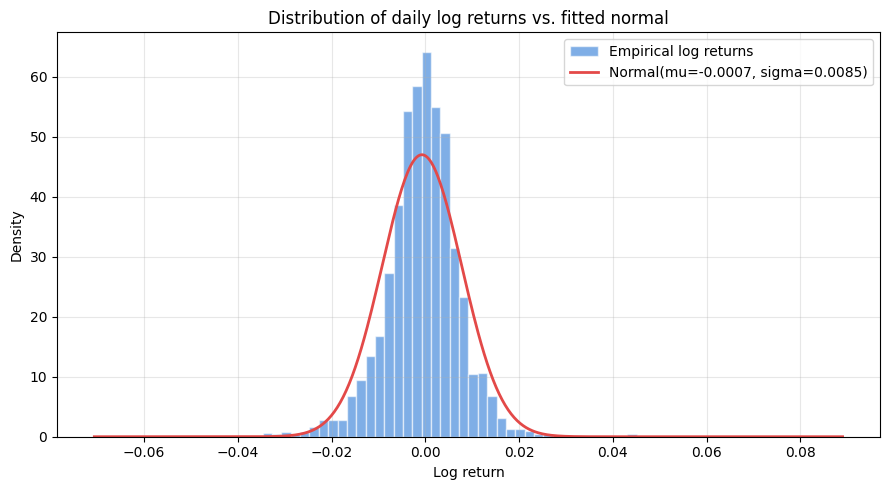

In [5]:
fig, ax = plt.subplots()
ax.hist(returns, bins=80, density=True, alpha=0.6, color='#2a78d6', edgecolor='white',
        label='Empirical log returns')

x = np.linspace(returns.min(), returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color='#e34948', lw=2,
        label=f'Normal(mu={mu:.4f}, sigma={sigma:.4f})')

ax.set_title('Distribution of daily log returns vs. fitted normal')
ax.set_xlabel('Log return')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Q-Q plot vs. normal distribution

**What this plot shows:** the data is sorted and each sorted return is paired with the
value a normal distribution would predict at that same rank (theoretical quantile). If
returns were normal, every point would sit on the 45-degree reference line. Departures
from the line — especially at the far left and right ends — indicate the empirical
distribution has heavier or lighter tails than normal at that quantile.


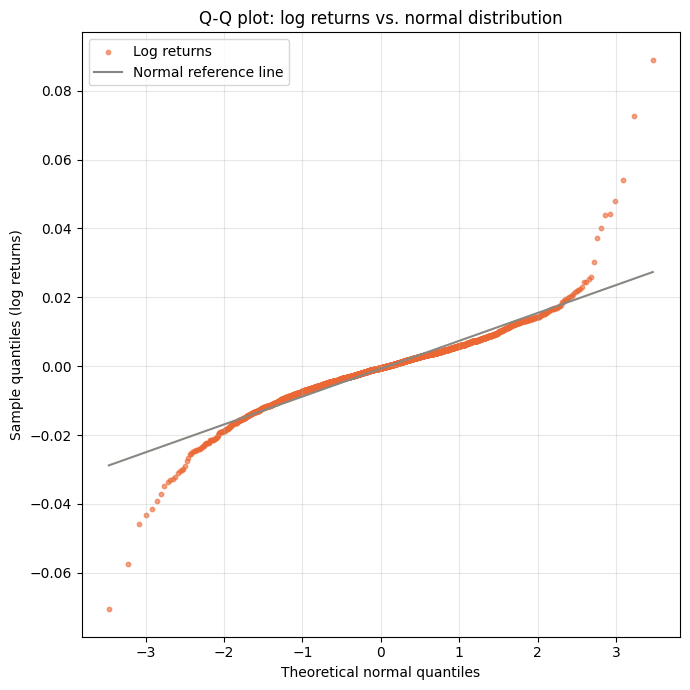

R^2 of the Q-Q fit (linearity check): 0.9076


In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

(osm, osr), (slope, intercept, r) = stats.probplot(returns, dist='norm')

ax.scatter(osm, osr, s=10, alpha=0.6, color='#eb6834', label='Log returns')
ax.plot(osm, slope * osm + intercept, color='#898781', lw=1.5, label='Normal reference line')

ax.set_title('Q-Q plot: log returns vs. normal distribution')
ax.set_xlabel('Theoretical normal quantiles')
ax.set_ylabel('Sample quantiles (log returns)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"R^2 of the Q-Q fit (linearity check): {r**2:.4f}")


**Reading the plot:** the middle ~80% of points (roughly -1.5 to +1.5 theoretical
standard deviations) sit close to the reference line — day-to-day returns in typical
conditions look reasonably normal-ish. Past that range, both tails bend sharply away
from the line: the left tail bends *downward* (worst days are more extreme than normal
predicts) and the right tail bends *upward* (best days are more extreme than normal
predicts). This is the textbook signature of **fat tails / excess kurtosis**, as
opposed to skew (which would show one tail deviating while the other stays on the
line) or thin tails (points bending *toward* the line at the ends).


## 6. Skewness and kurtosis

- **Skewness** measures asymmetry: 0 for a symmetric distribution, positive if the
  right tail is longer, negative if the left tail is longer.
- **Kurtosis (excess)** measures tail weight relative to normal: `scipy.stats.kurtosis`
  reports *excess* kurtosis, where 0 = normal. Positive excess kurtosis means more
  probability mass in the tails (and typically a sharper peak) than a normal
  distribution — i.e., rare extreme moves happen more often than a normal model would
  predict.


In [7]:
skew = stats.skew(returns)
excess_kurt = stats.kurtosis(returns)  # Fisher definition: normal = 0

print(f"Skewness:          {skew: .4f}")
print(f"Excess kurtosis:   {excess_kurt: .4f}   (normal distribution = 0)")
print(f"'Raw' kurtosis:    {excess_kurt + 3: .4f}   (normal distribution = 3)")


Skewness:           0.2385
Excess kurtosis:    12.0913   (normal distribution = 0)
'Raw' kurtosis:     15.0913   (normal distribution = 3)


**Interpretation:**
- Skewness is mildly positive (a slightly longer right tail), but small relative to
  the kurtosis effect — asymmetry is not the dominant story here.
- Excess kurtosis is very large (roughly 12 on this sample), far above what's typical
  even for daily equity/index returns (commonly cited in the 3-8 range). This
  quantifies what the Q-Q plot showed visually: extreme days are dramatically more
  frequent/severe than a normal distribution would imply.


## 7. Formal significance test — Jarque-Bera

The Jarque-Bera test formally tests the null hypothesis that a sample comes from a
normal distribution, using sample skewness and kurtosis. It is the appropriate
significance test to accompany the visual (histogram, Q-Q plot) and descriptive
(skew, kurtosis) evidence.
- **H0:** the data is drawn from a normal distribution.
- **Test statistic:** combines squared skewness and squared excess kurtosis; larger
  values indicate a bigger departure from normality.
- **Decision rule:** reject H0 if p-value < chosen significance level (alpha), commonly
  0.05.


In [8]:
jb_stat, jb_pvalue = stats.jarque_bera(returns)

alpha = 0.05
print(f"Jarque-Bera statistic: {jb_stat:,.2f}")
print(f"p-value:               {jb_pvalue:.6g}")
print(f"Significance level (alpha): {alpha}")

if jb_pvalue < alpha:
    print("\nResult: REJECT H0 -- returns are not consistent with a normal distribution.")
else:
    print("\nResult: fail to reject H0 -- no significant evidence against normality.")


Jarque-Bera statistic: 16,289.95
p-value:               0
Significance level (alpha): 0.05

Result: REJECT H0 -- returns are not consistent with a normal distribution.


**Result:** the Jarque-Bera statistic is extremely large and the p-value is
effectively zero, so the null hypothesis of normality is rejected by an overwhelming
margin. This is not a borderline or ambiguous case -- it is one of the more decisive
rejections one is likely to encounter in this kind of test, driven almost entirely by
the extreme kurtosis rather than the skew.


## 8. Sanity check — log vs. simple return identity

As a cross-check inherited from the Week 2 pipeline validation, confirm that
`log_return = ln(1 + simple_return)` holds across the sample. This doesn't test
normality, but it verifies the two return series used throughout this notebook (and
downstream weeks) are internally consistent.


In [9]:
check = np.log1p(simple_returns) - returns
max_abs_diff = check.abs().max()
print(f"Max abs difference between ln(1+simple_return) and log_return: {max_abs_diff:.2e}")
print("Identity holds within floating point tolerance." if max_abs_diff < 1e-8 else
      "WARNING: identity does not hold -- investigate pipeline.")


Max abs difference between ln(1+simple_return) and log_return: 9.90e-17
Identity holds within floating point tolerance.


## 9. Summary of findings

| Metric | Value | Interpretation |
|---|---|---|
| N (observations) | ~2,670 | 10 years of daily open-to-close returns |
| Mean | ~ -0.0007 | roughly flat/slightly negative daily drift over the sample |
| Std dev | ~ 0.0085 | typical daily move of about 0.85% |
| Skewness | ~ 0.24 | mild positive asymmetry, not the dominant feature |
| Excess kurtosis | ~ 12.1 | severe fat tails; extreme days far more likely than normal implies |
| Jarque-Bera stat / p-value | ~16,290 / ~0 | normality rejected with overwhelming significance |

**Bottom line:** Nifty 50 daily log returns are decisively non-normal, and the
departure is concentrated in the tails rather than in asymmetry. Any tool downstream
that assumes normal returns (basic VaR, z-score-based outlier filters,
Black-Scholes-style option pricing, naive Gaussian confidence intervals) will
systematically understate the probability and size of extreme moves on this asset.
